# Face Anonymization from 5 Given Landmarks (cedalion-only)

Pure-geometric face-removal pipeline for Einstar scans. Takes the 5 standard
anatomical landmarks (Nz, Iz, Cz, Lpa, Rpa) as input and deletes the facial
region without any ML / face-detection dependency.

**Pipeline:**
1. Load scan
2. Pick 5 landmarks interactively via `cedalion.plots.plot_surface(pick_landmarks=True)`
3. Wrap into a `LabeledPointCloud`
4. Normalize axes (X=up, Y=anterior, Z=left) and isolate head
5. Build face-region mask purely from the 5 landmarks
6. Visualize the mask
7. Delete masked vertices (no smoothing)
8. Validate result

This is the cedalion-only alternative to notebook 47's MediaPipe pipeline and
matches the exposé contract: NAS/LPA/RPA assumed given, no DL face detection.

In [15]:
import logging

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import xarray as xr

import cedalion
import cedalion.dataclasses as cdc
import cedalion.io
import cedalion.plots
from cedalion.geometry.photogrammetry.anonymization import (
    normalize_axes,
    isolate_head,
    validate_anonymization,
)
from cedalion.vtktutils import trimesh_to_vtk_polydata
from cedalion.dataclasses import VTKSurface

logging.getLogger('cedalion').setLevel(logging.WARNING)
pv.set_jupyter_backend('server')

# === CONFIG ===
SUBJECT_NUMBER = 17
SCANS_FOLDER = '/home/ma7/BA/PG_Subjects'

# True: run the picker. False: use cached landmarks (fill after first pick).
INTERACTIVE = True

# Mask tunables (mm)
LATERAL_SCALE = 0.9             # fraction of ear-half-width for main face mask
LANDMARK_KEEP_RADIUS = 8.0      # preserve a small sphere around each landmark point
EAR_DELETE_RADIUS_MM = 40.0     # radius of the delete sphere around Lpa / Rpa

# Cap boundary detection tunables
CAP_BAND_WIDTH_MM = 15.0        # Z-band width for midline Y-profile
CAP_BIN_SIZE_MM = 2.0           # X-bin size for Y-profile
CAP_FOOT_GRAD_THRESHOLD = 0.2   # dY/dX below this = flat = foot of cap rise

## 1. Load the Einstar scan

In [16]:
path = f'{SCANS_FOLDER}/Subject{SUBJECT_NUMBER}/Subject{SUBJECT_NUMBER}.obj'
surface = cedalion.io.read_einstar_obj(path)
print(f'Loaded: {surface.nvertices:,} vertices, {surface.nfaces:,} faces')

Loaded: 1,284,667 vertices, 2,223,716 faces


## 2. Pick the 5 landmarks interactively

Uses cedalion's built-in picker (`cedalion.plots.plot_surface(..., pick_landmarks=True)`,
authored by Mariia Iudina, upstream cedalion). Right-click on the mesh to place a
sphere; click again on the sphere to cycle its label through
`Nz -> Iz -> Cz -> Lpa -> Rpa`, or cycle past `Rpa` back to `Nz` to remove it.

Close the window when all 5 are placed with correct labels.

In [17]:
if INTERACTIVE:
    pvplt = pv.Plotter()
    get_landmarks = cedalion.plots.plot_surface(
        pvplt, surface, opacity=1.0, pick_landmarks=True
    )
    pvplt.show()

Widget(value='<iframe src="http://localhost:38789/index.html?ui=P_0x7f9c741e8a10_3&reconnect=auto" class="pyvi…

## 3. Retrieve picked points and wrap into a `LabeledPointCloud`

Follows the pattern from `41_photogrammetric_optode_coregistration.ipynb` cells 26-28.

In [18]:
if INTERACTIVE:
    landmark_coordinates, landmark_labels = get_landmarks()
    landmark_coordinates = np.asarray(landmark_coordinates)
else:
    # Cached fallback: paste coordinates from a previous interactive run here.
    landmark_labels = ['Nz', 'Iz', 'Cz', 'Lpa', 'Rpa']
    landmark_coordinates = np.asarray([
        [0.0, 0.0, 0.0],   # Nz  -- replace
        [0.0, 0.0, 0.0],   # Iz  -- replace
        [0.0, 0.0, 0.0],   # Cz  -- replace
        [0.0, 0.0, 0.0],   # Lpa -- replace
        [0.0, 0.0, 0.0],   # Rpa -- replace
    ])

assert len(set(landmark_labels)) == 5, 'Need exactly 5 distinct landmarks'
assert set(landmark_labels) == {'Nz', 'Iz', 'Cz', 'Lpa', 'Rpa'}, (
    f'Unexpected labels: {landmark_labels}'
)

landmarks = xr.DataArray(
    np.vstack(landmark_coordinates),
    dims=['label', 'digitized'],
    coords={
        'label': ('label', list(landmark_labels)),
        'type': ('label', [cdc.PointType.LANDMARK] * 5),
        'group': ('label', ['L'] * 5),
    },
).pint.quantify('mm')

display(landmarks)

Magnitude,[[65.80514234534597 -11.605171044162262 481.1656612460295] [182.6220307773288 116.67835657353872 431.57097619552144] [51.88537827784663 219.86486083549175 456.3823857394348] [64.75510597977373 78.3338583311504 566.3625948499965] [2.740867794190251 77.07375633870706 392.2325599877916]]
Units,millimeter


## 4. Normalize axes and isolate head

`normalize_axes` rotates the mesh around its X-axis so Y points anterior (toward
the face) and Z points left. We apply the same rotation to the 5 landmarks so
they stay consistent with the mesh. After this, the canonical frame is:
X=up, Y=anterior, Z=left.

In [19]:
# Extract raw coords (strip pint units) for geometric operations
lm_raw = landmarks.pint.dequantify().values  # (5, 3)
idx = {lbl: i for i, lbl in enumerate(landmarks['label'].values)}
Nz_raw = lm_raw[idx['Nz']]

# --- Step 1: Mediapipe-compatible normalization (kept for isolate_head) ---
surface_n, Nz_n, R = normalize_axes(surface, Nz_raw)
lm_n = lm_raw @ R.T

# Isolate head (needs normalize_axes frame)
surface_h, _ = isolate_head(surface_n, Nz_n)
print(f'After isolate_head: {surface_n.nvertices:,} -> {surface_h.nvertices:,} vertices')

# --- Step 2: Landmark-based axis alignment ---
# normalize_axes only rotates around X. The head is still tilted.
# Derive a full rotation from the 5 landmarks to align X=up, Y=anterior, Z=left.
Nz_1  = lm_n[idx['Nz']]
Iz_1  = lm_n[idx['Iz']]
Cz_1  = lm_n[idx['Cz']]
Lpa_1 = lm_n[idx['Lpa']]
Rpa_1 = lm_n[idx['Rpa']]
ear_mid_1 = 0.5 * (Lpa_1 + Rpa_1)

# Z: lateral (Lpa-Rpa line, pointing left) -- the most reliable axis
z_ax = Lpa_1 - Rpa_1
z_ax = z_ax / np.linalg.norm(z_ax)

# Y: anterior, perpendicular to Z, pointing out from nasion
nz_dir = Nz_1 - ear_mid_1
nz_dir = nz_dir - np.dot(nz_dir, z_ax) * z_ax
y_ax = nz_dir / np.linalg.norm(nz_dir)

# X: up, falls out as cross product
x_ax = np.cross(y_ax, z_ax)

# Sign checks
if np.dot(Cz_1 - ear_mid_1, x_ax) < 0:
    x_ax = -x_ax
if np.dot(Nz_1 - ear_mid_1, y_ax) < 0:
    y_ax = -y_ax
z_ax = np.cross(x_ax, y_ax)

print(f'Landmark-derived axes (before rotation):')
print(f'  z_ax (lateral):  {z_ax}  <-- from Lpa-Rpa')
print(f'  y_ax (anterior): {y_ax}  <-- perp to Z, toward Nz')
print(f'  x_ax (up):       {x_ax}  <-- cross(Y, Z)')

# R2 maps the landmark frame to the standard basis
R2 = np.vstack([x_ax, y_ax, z_ax])

# Apply to mesh vertices
import trimesh
aligned_verts = np.asarray(surface_h.mesh.vertices) @ R2.T
surface_h = cdc.TrimeshSurface(
    trimesh.Trimesh(vertices=aligned_verts, faces=surface_h.mesh.faces,
                    visual=surface_h.mesh.visual, process=False),
    crs=surface_h.crs, units=surface_h.units,
)

# Apply to landmarks
lm_n = lm_n @ R2.T

# Rebuild LabeledPointCloud
landmarks_n = xr.DataArray(
    lm_n,
    dims=['label', 'digitized'],
    coords={
        'label': ('label', list(landmarks['label'].values)),
        'type': ('label', [cdc.PointType.LANDMARK] * 5),
        'group': ('label', ['L'] * 5),
    },
).pint.quantify('mm')

# Named references in the fully aligned frame
Nz  = lm_n[idx['Nz']]
Iz  = lm_n[idx['Iz']]
Cz  = lm_n[idx['Cz']]
Lpa = lm_n[idx['Lpa']]
Rpa = lm_n[idx['Rpa']]
ear_mid = 0.5 * (Lpa + Rpa)

print(f'\nAligned landmarks (X=up, Y=anterior, Z=left):')
print(f'  Nz : {Nz}')
print(f'  Iz : {Iz}')
print(f'  Cz : {Cz}')
print(f'  Lpa: {Lpa}')
print(f'  Rpa: {Rpa}')

print(f'\nAxis checks:')
print(f'  Cz highest X (up)?      {Cz[0] > max(Nz[0], Iz[0], Lpa[0], Rpa[0])}')
print(f'  Nz most anterior (Y)?   {Nz[1] > max(Iz[1], Lpa[1], Rpa[1])}')
print(f'  Lpa left of Rpa (Z)?    {Lpa[2] > Rpa[2]}')
print(f'  Lpa/Rpa same X (height)? {abs(Lpa[0] - Rpa[0]):.1f} mm')
print(f'  Lpa/Rpa same Y (depth)?  {abs(Lpa[1] - Rpa[1]):.1f} mm')
print(f'  Nz/Iz same X (height)?   {abs(Nz[0] - Iz[0]):.1f} mm')

mesh_verts = np.asarray(surface_h.mesh.vertices)
for lbl, pos in zip(['Nz','Iz','Cz','Lpa','Rpa'], [Nz, Iz, Cz, Lpa, Rpa]):
    d = np.linalg.norm(mesh_verts - pos, axis=1).min()
    print(f'  {lbl} on mesh: {d:.2f} mm')

After isolate_head: 1,284,667 -> 678,081 vertices
Landmark-derived axes (before rotation):
  z_ax (lateral):  [-0.33548853 -0.12505766  0.93370661]  <-- from Lpa-Rpa
  y_ax (anterior): [0.29804451 0.92614585 0.23113487]  <-- perp to Z, toward Nz
  x_ax (up):       [ 0.89365369 -0.35582923  0.27343856]  <-- cross(Y, Z)

Aligned landmarks (X=up, Y=anterior, Z=left):
  Nz : [ -99.06892144  -17.13701132 -475.26525432]
  Iz : [ -30.86680258 -238.5773692  -448.82692759]
  Cz : [  61.51173772  -99.18613518 -468.61131999]
  Lpa: [ -99.06892144 -111.29378165 -370.9357092 ]
  Rpa: [ -99.06892144 -111.29378165 -555.78327514]

Axis checks:
  Cz highest X (up)?      True
  Nz most anterior (Y)?   True
  Lpa left of Rpa (Z)?    True
  Lpa/Rpa same X (height)? 0.0 mm
  Lpa/Rpa same Y (depth)?  0.0 mm
  Nz/Iz same X (height)?   68.2 mm
  Nz on mesh: 0.20 mm
  Iz on mesh: 0.17 mm
  Cz on mesh: 0.78 mm
  Lpa on mesh: 0.71 mm
  Rpa on mesh: 1.00 mm


## 5. Build the face-region mask from the 5 landmarks

Two parts:

1. **Cap boundary detection:** Scan upward from Nz along the midline. In each
   height bin, find the most anterior vertex (max Y). The forehead shows a smooth
   Y decrease; the cap edge shows a sudden Y drop. The X value where that drop
   first exceeds `CAP_GRADIENT_THRESHOLD` is `cap_x`.

2. **Mask rules** (in the aligned frame X=up, Y=anterior, Z=left):
   - `X < cap_x` (below the cap boundary -- covers face + forehead)
   - `Y > ear_mid_y` (anterior to the coronal ear plane)
   - `|Z - mid_z| < half_width` (within lateral width, ears excluded)

Cap boundary detected at X = -58.1 mm
  Nz_x = -99.1,  Cz_x = 61.5,  cap_x = -58.1


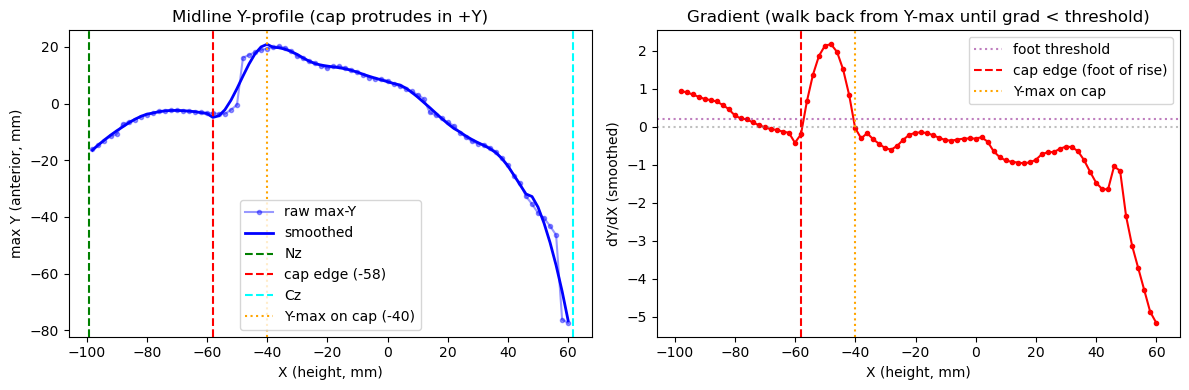

Nasion strip preserved: 1,963 vertices (half-width 8 mm, X: -99 -> -58)

Mask: 142,911 / 678,081 vertices (21.1%)
Per-rule counts: {'below_cap': 364330, 'face_region': 126927, 'ear_region': 42118, 'all': 146319}
Ear delete radius: 40 mm


In [20]:
from scipy.signal import savgol_filter


def detect_cap_boundary(
    verts: np.ndarray,
    Nz: np.ndarray, Cz: np.ndarray, ear_mid: np.ndarray,
    mid_z: float,
    band_width: float = 15.0,
    bin_size: float = 2.0,
    foot_grad_threshold: float = 0.2,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    """Find the X height where the cap front edge sits.

    The cap protrudes in +Y, so Y-max along the midline lives ON the cap.
    The cap edge is the FOOT of the steep rise leading up to Y-max: walk back
    from the peak until the smoothed gradient drops below `foot_grad_threshold`.
    """
    in_band = np.abs(verts[:, 2] - mid_z) < band_width
    above_nz = verts[:, 0] > Nz[0]
    anterior = verts[:, 1] > ear_mid[1]
    sel = in_band & above_nz & anterior
    sel_verts = verts[sel]

    bins = np.arange(Nz[0], Cz[0], bin_size)
    bin_centers = bins[:-1] + bin_size / 2
    max_y = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_centers)):
        in_bin = (sel_verts[:, 0] >= bins[i]) & (sel_verts[:, 0] < bins[i + 1])
        if in_bin.any():
            max_y[i] = sel_verts[in_bin, 1].max()

    valid = ~np.isnan(max_y)
    if valid.sum() < 7:
        fallback = 0.5 * (Nz[0] + Cz[0])
        return fallback, bin_centers[valid], max_y[valid], max_y[valid]

    xv = bin_centers[valid]
    yv = max_y[valid]

    win = min(11, len(yv) if len(yv) % 2 == 1 else len(yv) - 1)
    win = max(win, 5)
    yv_s = savgol_filter(yv, window_length=win, polyorder=2)

    peak_idx = int(np.argmax(yv_s))
    grad = np.gradient(yv_s, xv)
    cap_x = xv[0]
    for i in range(peak_idx - 1, 0, -1):
        if grad[i] < foot_grad_threshold:
            cap_x = xv[i]
            break

    return cap_x, xv, yv, yv_s


def face_mask_from_landmarks(
    verts, Nz, Iz, Cz, Lpa, Rpa,
    cap_x=None,
    ear_delete_radius=40.0,
):
    """Connected face + ear mask in the aligned frame (X=up, Y=ant, Z=left).

    The mask is the union of two regions, both clamped below the cap boundary:
      1. Face region: anterior to the ear coronal plane, extending laterally
         all the way to the ears (no midline band -- so it connects with the
         ear spheres below).
      2. Ear spheres: `ear_delete_radius` mm around Lpa and Rpa (deletes the
         ears themselves plus a bit of skin behind them).

    Cap safety comes from the `below_cap` clamp (X < cap_x).
    """
    ear_mid = 0.5 * (Lpa + Rpa)
    upper_bound = cap_x if cap_x is not None else Nz[0]

    below_cap = verts[:, 0] < upper_bound
    anterior  = verts[:, 1] > ear_mid[1]

    face_region = below_cap & anterior

    d_lpa = np.linalg.norm(verts - Lpa, axis=1)
    d_rpa = np.linalg.norm(verts - Rpa, axis=1)
    ear_region = ((d_lpa < ear_delete_radius) | (d_rpa < ear_delete_radius)) & below_cap

    mask = face_region | ear_region

    info = {
        'upper_bound': upper_bound, 'ear_mid': ear_mid,
        'counts': {
            'below_cap': int(below_cap.sum()),
            'face_region': int(face_region.sum()),
            'ear_region': int(ear_region.sum()),
            'all': int(mask.sum()),
        },
    }
    return mask, info


# --- Detect cap boundary ---
verts = np.asarray(surface_h.mesh.vertices)
mid_z = 0.5 * (Lpa[2] + Rpa[2])

cap_x, profile_x, profile_y, profile_y_s = detect_cap_boundary(
    verts, Nz, Cz, ear_mid, mid_z,
    band_width=CAP_BAND_WIDTH_MM,
    bin_size=CAP_BIN_SIZE_MM,
    foot_grad_threshold=CAP_FOOT_GRAD_THRESHOLD,
)
print(f'Cap boundary detected at X = {cap_x:.1f} mm')
print(f'  Nz_x = {Nz[0]:.1f},  Cz_x = {Cz[0]:.1f},  cap_x = {cap_x:.1f}')

# Debug plot: Y-profile along midline (raw + smoothed)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(profile_x, profile_y, 'b.-', alpha=0.4, label='raw max-Y')
ax1.plot(profile_x, profile_y_s, 'b-', lw=2, label='smoothed')
ax1.axvline(Nz[0], color='green', ls='--', label='Nz')
ax1.axvline(cap_x, color='red', ls='--', label=f'cap edge ({cap_x:.0f})')
ax1.axvline(Cz[0], color='cyan', ls='--', label='Cz')
peak_i = int(np.argmax(profile_y_s))
ax1.axvline(profile_x[peak_i], color='orange', ls=':',
            label=f'Y-max on cap ({profile_x[peak_i]:.0f})')
ax1.set_xlabel('X (height, mm)')
ax1.set_ylabel('max Y (anterior, mm)')
ax1.set_title('Midline Y-profile (cap protrudes in +Y)')
ax1.legend()

grad = np.gradient(profile_y_s, profile_x)
ax2.plot(profile_x, grad, 'r.-')
ax2.axhline(0, color='gray', ls=':', alpha=0.5)
ax2.axhline(CAP_FOOT_GRAD_THRESHOLD, color='purple', ls=':', alpha=0.5,
            label='foot threshold')
ax2.axvline(cap_x, color='red', ls='--', label='cap edge (foot of rise)')
ax2.axvline(profile_x[peak_i], color='orange', ls=':', label='Y-max on cap')
ax2.set_xlabel('X (height, mm)')
ax2.set_ylabel('dY/dX (smoothed)')
ax2.set_title('Gradient (walk back from Y-max until grad < threshold)')
ax2.legend()
plt.tight_layout()
plt.show()

# --- Build mask ---
mask, mask_info = face_mask_from_landmarks(
    verts, Nz, Iz, Cz, Lpa, Rpa,
    cap_x=cap_x,
    ear_delete_radius=EAR_DELETE_RADIUS_MM,
)

# Preserve the 5 landmark points (small keep-out sphere around each)
for lm in (Nz, Iz, Cz, Lpa, Rpa):
    near = np.linalg.norm(verts - lm, axis=1) < LANDMARK_KEEP_RADIUS
    mask[near] = False

# Supervisor request: preserve a rectangular strip from the Nasion upward to
# the cap boundary, width = the Nasion's safe-area diameter (for coregistration).
strip_half_width = LANDMARK_KEEP_RADIUS
nasion_strip = (
    (verts[:, 0] >= Nz[0]) &
    (verts[:, 0] < cap_x) &
    (np.abs(verts[:, 2] - Nz[2]) < strip_half_width) &
    (verts[:, 1] > ear_mid[1])
)
mask[nasion_strip] = False
print(f'Nasion strip preserved: {int(nasion_strip.sum()):,} vertices '
      f'(half-width {strip_half_width:.0f} mm, X: {Nz[0]:.0f} -> {cap_x:.0f})')

print(f'\nMask: {mask.sum():,} / {len(mask):,} vertices '
      f'({100*mask.sum()/len(mask):.1f}%)')
print(f'Per-rule counts: {mask_info["counts"]}')
print(f'Ear delete radius: {EAR_DELETE_RADIUS_MM:.0f} mm')

## 6. Visualize the anonymization mask

Red = will be deleted, white = kept. The 5 landmark spheres are overlaid for
orientation. This is the primary deliverable — if the red region hugs the face
without leaking onto ears / top-of-head / neck, the geometric rules are working.

In [21]:
pvplt = pv.Plotter()

vtk_surface = VTKSurface.from_trimeshsurface(surface_h)
pv_mesh = pv.wrap(vtk_surface.mesh)
pv_mesh['mask'] = mask.astype(float)
pvplt.add_mesh(
    pv_mesh, scalars='mask', cmap=['white', 'red'], clim=[0, 1],
    show_scalar_bar=False, opacity=1.0, smooth_shading=True,
)

# 5 landmark spheres with labels
lm_colors = {'Nz': 'lime', 'Iz': 'magenta', 'Cz': 'cyan', 'Lpa': 'orange', 'Rpa': 'blue'}
for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    c = lm_colors.get(lbl, 'yellow')
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos), color=c)
    pvplt.add_point_labels(
        [pos], [lbl], font_size=16, text_color=c, shape=None, always_visible=True,
    )

pvplt.add_text(
    f'S{SUBJECT_NUMBER} | mask: {mask.sum():,} / {len(mask):,} verts '
    f'({100*mask.sum()/len(mask):.1f}%)',
    position='upper_left', font_size=12,
)
pvplt.show()

Widget(value='<iframe src="http://localhost:38789/index.html?ui=P_0x7f9bdeb63bd0_4&reconnect=auto" class="pyvi…

## 7. Anonymize by deleting masked vertices

Drops every triangle that has any masked vertex, then strips unreferenced
vertices. Pure trimesh, no smoothing.

In [22]:
mesh_copy = surface_h.mesh.copy()
face_verts_in_mask = mask[mesh_copy.faces]        # (n_faces, 3) bool
faces_to_remove = face_verts_in_mask.any(axis=1)
mesh_copy.update_faces(~faces_to_remove)
mesh_copy.remove_unreferenced_vertices()

surface_anon = cdc.TrimeshSurface(
    mesh=mesh_copy, crs=surface_h.crs, units=surface_h.units,
)

n_removed = surface_h.nvertices - surface_anon.nvertices
print(f'Original:    {surface_h.nvertices:,} verts, {surface_h.nfaces:,} faces')
print(f'Anonymized:  {surface_anon.nvertices:,} verts, {surface_anon.nfaces:,} faces')
print(f'Removed:     {n_removed:,} verts')

Original:    678,081 verts, 1,171,705 faces
Anonymized:  535,017 verts, 920,914 faces
Removed:     143,064 verts


## 8. Before / after

In [23]:
anon_vtk = trimesh_to_vtk_polydata(mesh_copy)

pvplt = pv.Plotter(shape=(1, 2))

pvplt.subplot(0, 0)
cedalion.plots.plot_surface(pvplt, surface_h, opacity=1.0)
for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos),
                   color=lm_colors.get(lbl, 'yellow'))
pvplt.add_text(f'S{SUBJECT_NUMBER} Original', position='upper_left', font_size=14)

pvplt.subplot(0, 1)
pvplt.add_mesh(pv.wrap(anon_vtk), rgb=True, smooth_shading=True)
for lbl, pos in zip(landmarks_n['label'].values, lm_n):
    pvplt.add_mesh(pv.Sphere(radius=4, center=pos),
                   color=lm_colors.get(lbl, 'yellow'))
pvplt.add_text(
    f'S{SUBJECT_NUMBER} Anonymized (-{n_removed:,} verts)',
    position='upper_left', font_size=14,
)

pvplt.link_views()
pvplt.show()

Widget(value='<iframe src="http://localhost:38789/index.html?ui=P_0x7f9c4c6cc0d0_5&reconnect=auto" class="pyvi…

## 9. Validate

Sanity-check the result: vertex count dropped, no degenerate faces, landmarks
still reachable on the anonymized surface.

In [101]:
result = validate_anonymization(
    original_surface=surface_h,
    anonymized_surface=surface_anon,
    facial_mask=mask,
    protected_points=landmarks_n,
    tolerance=5.0 * cedalion.units.mm,
)
print(result)

ValidationResult(face_removed=True, mesh_valid=True, expected_vertices_removed=117152, actual_vertices_removed=117230, protected_points_intact=True, protected_point_max_deviation=0.3121421099641441, face_coverage_pct=23.709748253927778, passed=True, summary='PASSED — 117,230 vertices removed (23.7%), mesh valid, protected points within 5.0mm')


## Notes

- **Landmarks used:** 5 given (Nz, Iz, Cz, Lpa, Rpa), acquired via the existing
  upstream cedalion picker.
- **Mask thresholds:** `MARGIN_TOP_MM=0`, `MARGIN_BOTTOM_MM=20`, `LATERAL_SCALE=0.9`
  (tunable at the top of the notebook).
- **Anonymization method:** vertex deletion (drop faces touching masked vertices,
  strip unreferenced vertices). No Taubin smoothing. No MediaPipe.
- **Contract with the exposé:** this notebook assumes NAS/LPA/RPA are given and
  uses no DL face detection. Cz and Iz are also given and used as vertical bounds;
  they aren't strictly required but make the top/bottom cuts landmark-driven
  instead of mesh-extent-driven.
- **Relationship to notebook 47:** this is the cedalion-only alternative path.
  Notebook 47 detects Nz via MediaPipe and uses a face-oval contour for the
  upper mask bound; this notebook derives everything from the 5 given landmarks.